# Seasonal Agriculture Performance Analysis
# Major Data Analytics Project

Domian: Agriculture

Project Theme: Seasonal Agriculture Performance

Tools: Python, Pandas , NumPy , Matplotlib, Seaborn.




# Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.



# Project Objectives
-Understand the structure and quality of the agricultural dataset.

-Clean and prepare the data for analysis.

-Explore seasonal patterns in the dataset.

-Perform descriptive and statistical analysis.

-Investigate relationships among relevant variables.

-Compare agricultural performance across seasons and other meaningful groups.

-Use appropriate univariate, bivariate and multivariate visualizations.

-Identify significant findings from the data.

-Develop evidence-based insights and recommendations.

In [7]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from scipy import stats    # Statistical tests (for seasonal comparisons later)
# Display settings for cleaner outputs
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

# Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

Dataset file: seasonal_agriculture_performance_dataset.csv

In [9]:
# 1.load the dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Dataset loaded successfully.
Rows: 4000, Columns: 28


In [10]:
# 2.Initial Exploration
# upper 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [11]:
# bottom 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [12]:
# Random sample of record
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,7.10,12.9,108.0,75.8,96.5,Flood,228.2,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,7.66,24.3,97.8,36.7,96.0,Drip,65.9,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,6.33,30.4,149.3,41.8,98.8,Drip,143.0,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,7.57,24.5,118.6,77.5,128.7,Rainfed,116.4,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,7.31,18.9,45.8,79.9,126.7,Flood,242.8,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [13]:
# column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [14]:
# Numerical summary statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [15]:
print("Shape:", df.shape)
print()
df.info()

Shape: (4000, 28)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha               

In [16]:
# Data type of every column
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [17]:
# 3.Data Cleaning
## check missing values in each coulmn
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Pct': missing_pct
})

missing_summary = missing_summary[
    missing_summary['Missing_Count'] > 0
].sort_values('Missing_Count', ascending=False)

missing_summary




,Missing_Count,Missing_Pct
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [18]:
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

Total missing values: 120


In [19]:
# Handle missing values
for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    df[col] = df.groupby('Season')[col].transform(
        lambda x: x.fillna(x.median())
    )

df['Yield_Tonnes_Ha'] = df.groupby('Crop')['Yield_Tonnes_Ha'].transform(
    lambda x: x.fillna(x.median())
)

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [20]:
# Duplicates
full_duplicates = df.duplicated().sum()
id_duplicates = df.duplicated(subset=['Farm_ID']).sum()

print("Duplicate rows:", full_duplicates)
print("Duplicate Farm_IDs:", id_duplicates)

df = df.drop_duplicates()

print("Shape after removing duplicate rows:", df.shape)

Duplicate rows: 0
Duplicate Farm_IDs: 0
Shape after removing duplicate rows: (4000, 28)


In [21]:
# check data types again
df.dtypes


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [22]:
#  4.Descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.714313,288.427366,80.000,370.425,581.0000,836.12500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.504525,6.696998,8.000,21.700,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [23]:

categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
for col in categorical_cols:
    top_value = df[col].mode()[0]
    top_count = df[col].value_counts().iloc[0]
    print(f"{col}: {df[col].nunique()} unique values | most common = '{top_value}' ({top_count} records)")

State: 8 unique values | most common = 'Andhra Pradesh' (529 records)
District: 10 unique values | most common = 'Ludhiana' (427 records)
Crop: 8 unique values | most common = 'Rice' (690 records)
Season: 3 unique values | most common = 'Kharif' (1779 records)
Irrigation_Method: 4 unique values | most common = 'Flood' (1310 records)


In [24]:
# Skewness
outcome_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']
skew_table = df[outcome_cols].skew().sort_values(ascending=False)
print("Skewness (0 = symmetric, greater than 1 = strongly right-skewed):")
print(skew_table.round(2))

Skewness (0 = symmetric, greater than 1 = strongly right-skewed):
Production_Tonnes                5.13
Water_Efficiency_t_per_1000m3    4.28
Yield_Tonnes_Ha                  4.04
Profit_INR                       2.42
Revenue_INR                      2.29
dtype: float64


In [25]:
# 5.Outlier analysis
# IQR-based outlier detection for every numeric column
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Farm_ID', errors='ignore')

outlier_report = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_report.append([col, n_outliers, round(n_outliers / len(df) * 100, 2)])

outlier_df = pd.DataFrame(outlier_report, columns=['Column', 'Outlier_Count', 'Outlier_Pct']).sort_values('Outlier_Pct', ascending=False)
outlier_df

,Column,Outlier_Count,Outlier_Pct
18,Profit_INR,404,10.10
14,Production_Tonnes,333,8.33
20,Water_Efficiency_t_per_1000m3,322,8.05
13,Yield_Tonnes_Ha,304,7.60
19,Water_Used_m3,276,6.90
17,Revenue_INR,240,6.00
9,Potassium_kg_ha,32,0.80
4,Sunlight_Hours_Day,26,0.65
8,Phosphorus_kg_ha,16,0.40
10,Fertilizer_kg_ha,15,0.38


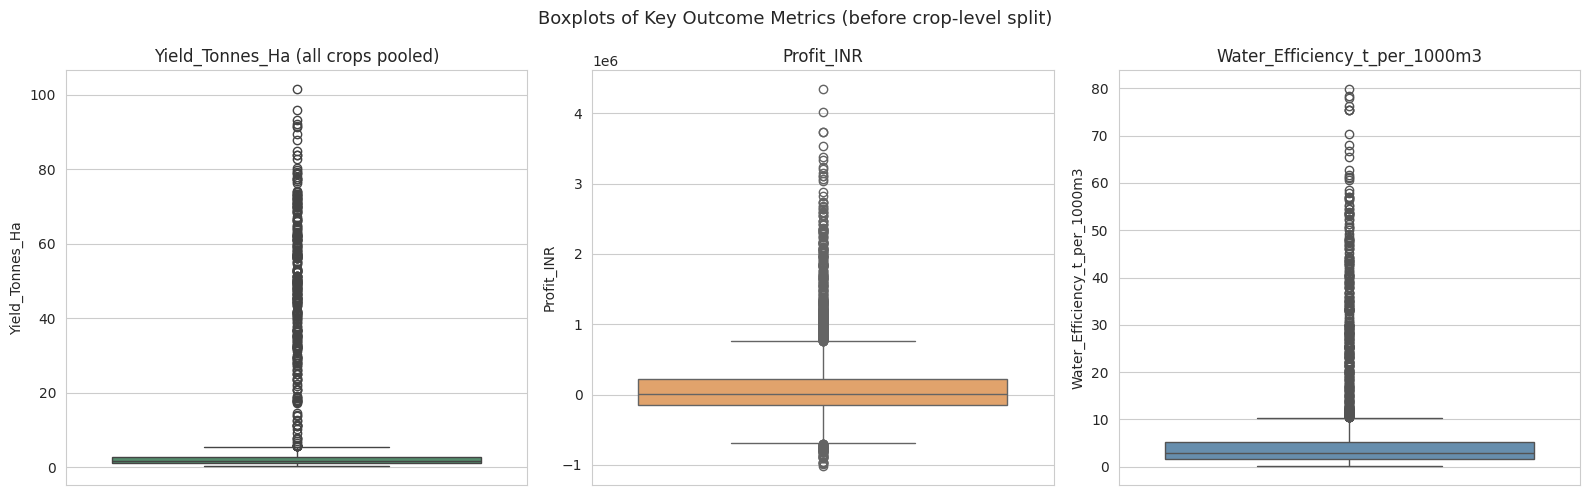

In [26]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=axes[0], color='#4C956C')
axes[0].set_title('Yield_Tonnes_Ha (all crops pooled)')

sns.boxplot(y=df['Profit_INR'], ax=axes[1], color='#F4A259')
axes[1].set_title('Profit_INR')

sns.boxplot(y=df['Water_Efficiency_t_per_1000m3'], ax=axes[2], color='#5B8FB9')
axes[2].set_title('Water_Efficiency_t_per_1000m3')

plt.suptitle('Boxplots of Key Outcome Metrics (before crop-level split)', fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
# Investigate yield outliers
# Check which crop the Yield outliers belong to
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
yield_outliers = df[df['Yield_Tonnes_Ha'] > upper_bound]

print(f"Total Yield_Tonnes_Ha outliers: {len(yield_outliers)}")
print()
print("Crop breakdown of those outliers:")
print(yield_outliers['Crop'].value_counts())

Total Yield_Tonnes_Ha outliers: 304

Crop breakdown of those outliers:
Crop
Sugarcane    295
Maize          7
Rice           2
Name: count, dtype: int64


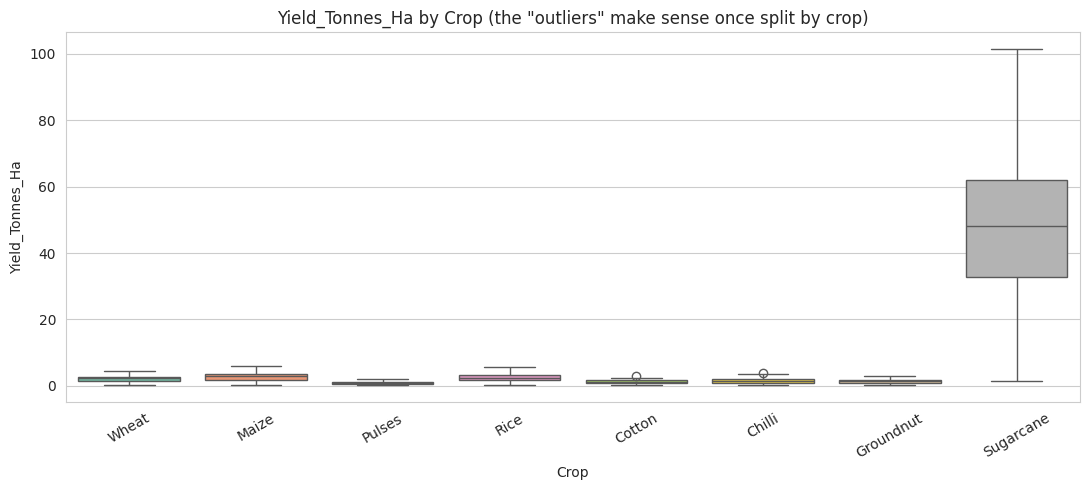

In [28]:
#  Crop-wise yield
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Crop', palette='Set2', legend=False)
plt.title('Yield_Tonnes_Ha by Crop (the "outliers" make sense once split by crop)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

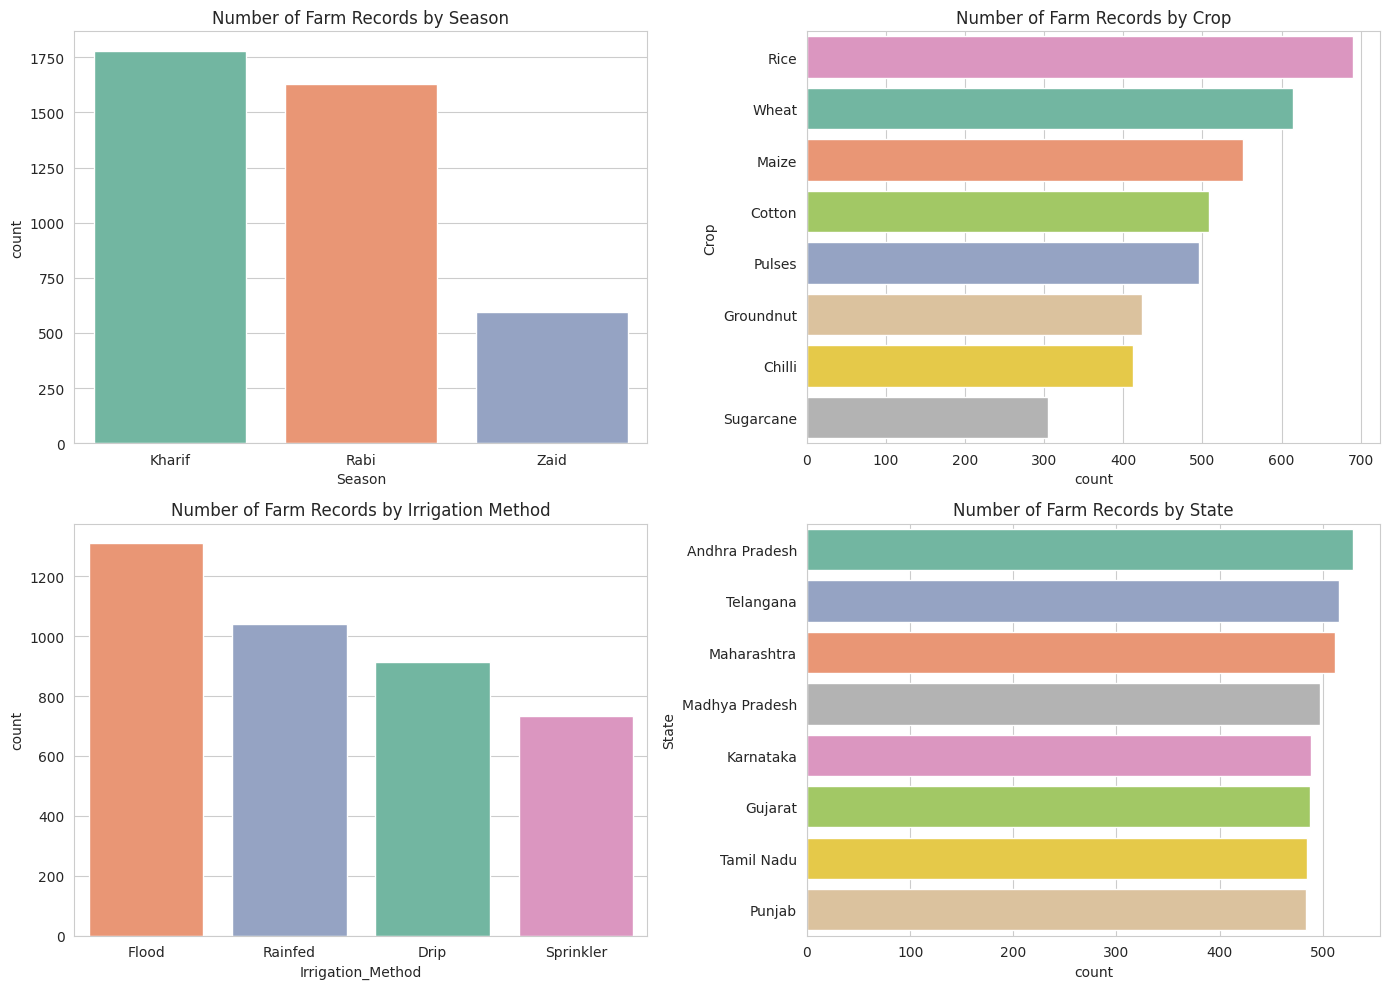

In [47]:
 # 6.Univariate analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='Season', order=df['Season'].value_counts().index, hue='Season', palette='Set2', ax=axes[0,0], legend=False)
axes[0,0].set_title('Number of Farm Records by Season')

sns.countplot(data=df, y='Crop', order=df['Crop'].value_counts().index, hue='Crop', palette='Set2', ax=axes[0,1], legend=False)
axes[0,1].set_title('Number of Farm Records by Crop')

sns.countplot(data=df, x='Irrigation_Method', order=df['Irrigation_Method'].value_counts().index, hue='Irrigation_Method', palette='Set2', ax=axes[1,0], legend=False)
axes[1,0].set_title('Number of Farm Records by Irrigation Method')

sns.countplot(data=df, y='State', order=df['State'].value_counts().index, hue='State', palette='Set2', ax=axes[1,1], legend=False)
axes[1,1].set_title('Number of Farm Records by State')

plt.tight_layout()
plt.show()

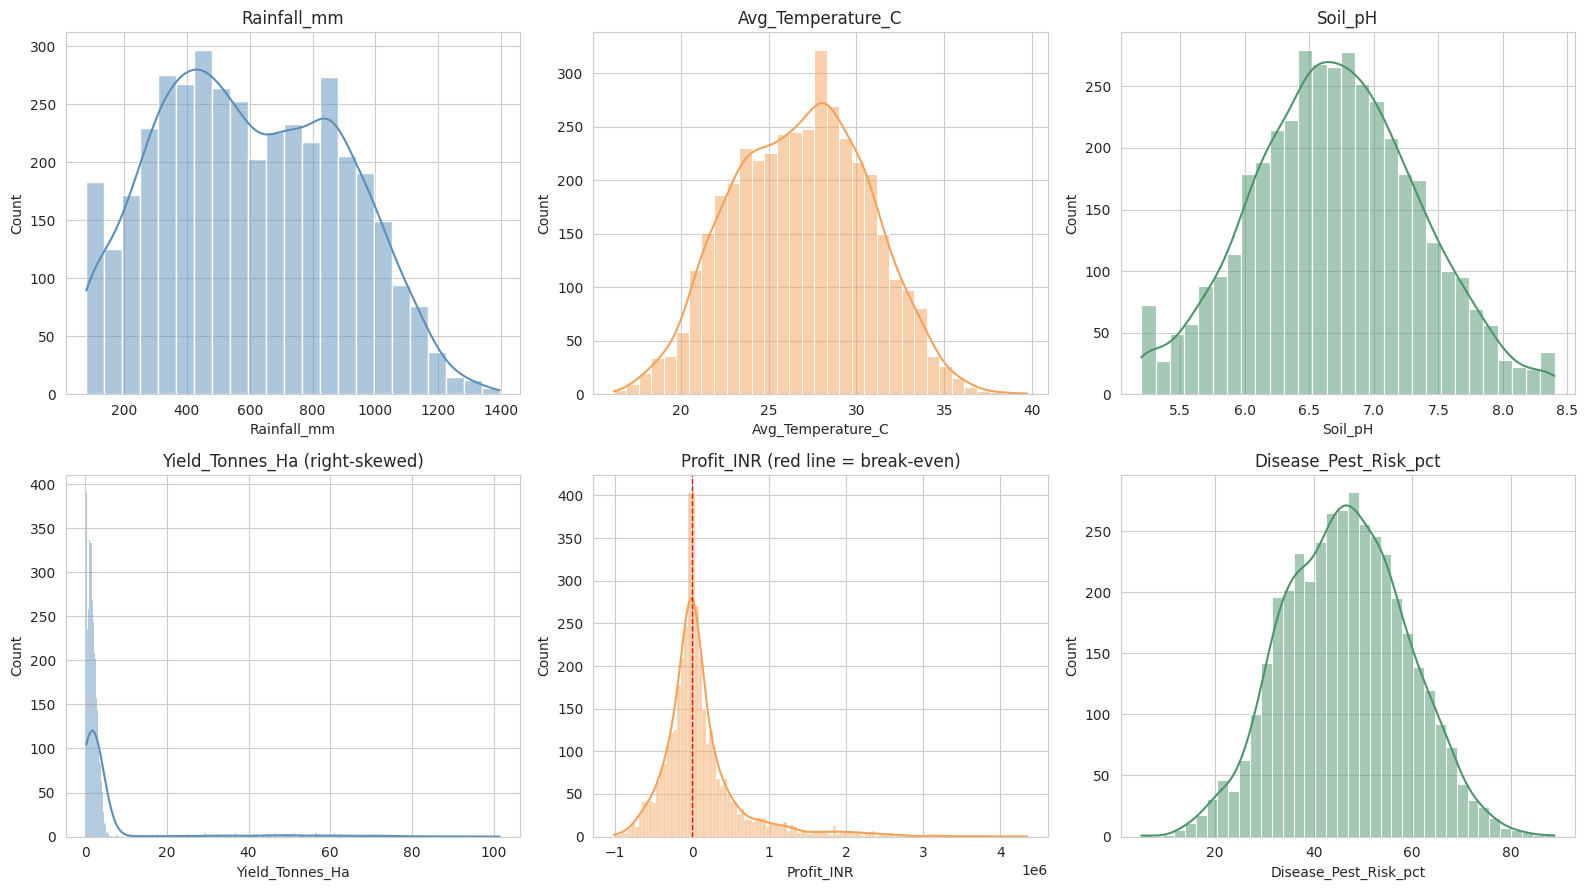

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df['Rainfall_mm'], kde=True, ax=axes[0,0], color='#5B8FB9')
axes[0,0].set_title('Rainfall_mm')

sns.histplot(df['Avg_Temperature_C'], kde=True, ax=axes[0,1], color='#F4A259')
axes[0,1].set_title('Avg_Temperature_C')

sns.histplot(df['Soil_pH'], kde=True, ax=axes[0,2], color='#4C956C')
axes[0,2].set_title('Soil_pH')

sns.histplot(df['Yield_Tonnes_Ha'], kde=True, ax=axes[1,0], color='#5B8FB9')
axes[1,0].set_title('Yield_Tonnes_Ha (right-skewed)')

sns.histplot(df['Profit_INR'], kde=True, ax=axes[1,1], color='#F4A259')
axes[1,1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1,1].set_title('Profit_INR (red line = break-even)')

sns.histplot(df['Disease_Pest_Risk_pct'], kde=True, ax=axes[1,2], color='#4C956C')
axes[1,2].set_title('Disease_Pest_Risk_pct')

plt.tight_layout()
plt.show()

In [31]:
# What share of farms are actually loss-making?
loss_making_pct = (df['Profit_INR'] < 0).mean() * 100
print(f"Farms with negative profit: {loss_making_pct:.1f}% of all {len(df)} records")

Farms with negative profit: 49.1% of all 4000 records


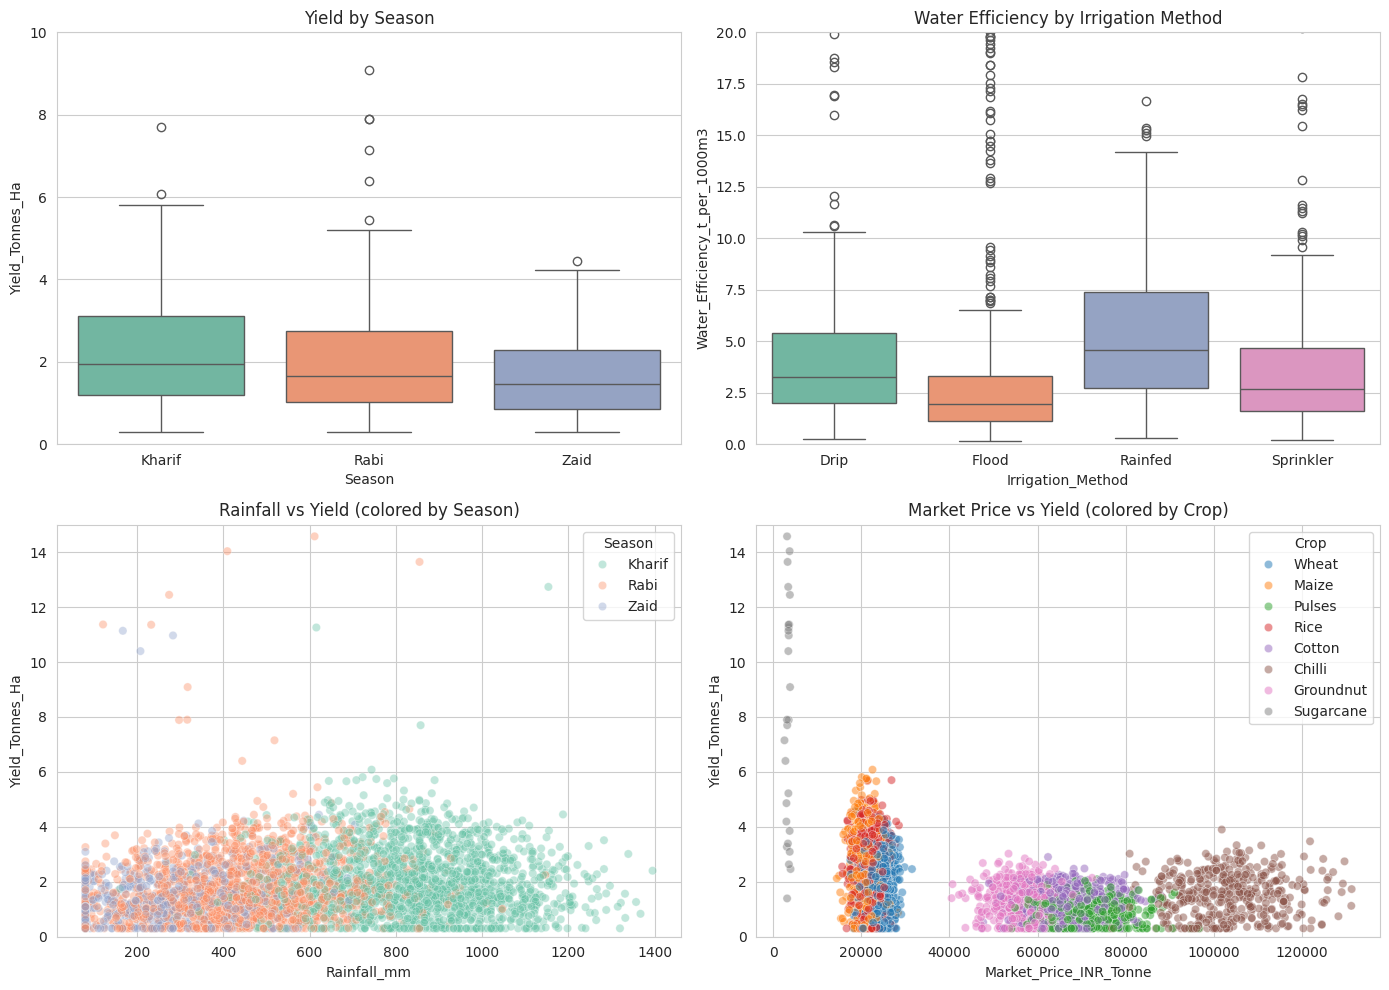

In [32]:
# 7.Bivariate analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Season', order=['Kharif','Rabi','Zaid'], palette='Set2', ax=axes[0,0], legend=False)
axes[0,0].set_title('Yield by Season')
axes[0,0].set_ylim(0, 10)

sns.boxplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Irrigation_Method', palette='Set2', ax=axes[0,1], legend=False)
axes[0,1].set_title('Water Efficiency by Irrigation Method')
axes[0,1].set_ylim(0, 20)

sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.4, palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Rainfall vs Yield (colored by Season)')
axes[1,0].set_ylim(0, 15)

sns.scatterplot(data=df, x='Market_Price_INR_Tonne', y='Yield_Tonnes_Ha', hue='Crop', alpha=0.5, palette='tab10', ax=axes[1,1])
axes[1,1].set_title('Market Price vs Yield (colored by Crop)')
axes[1,1].set_ylim(0, 15)

plt.tight_layout()
plt.show()

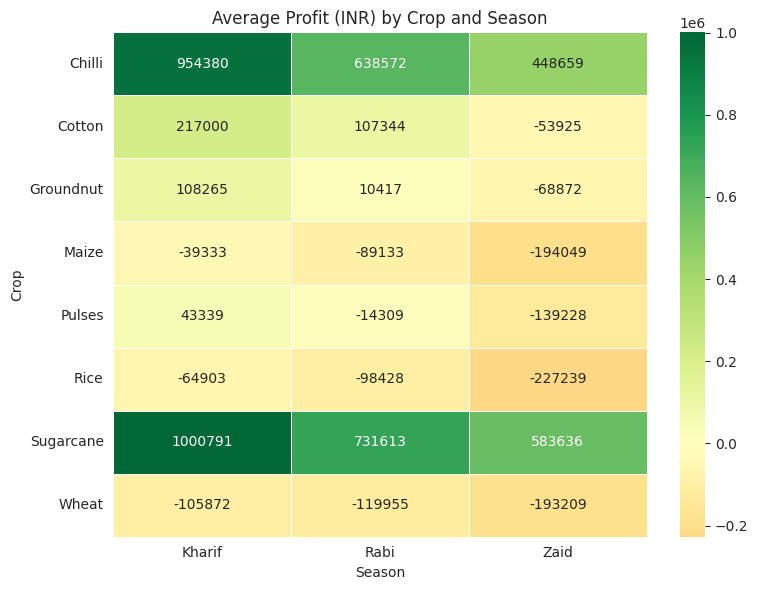

In [33]:
# 8.Multivariate analysis
# Mean profit for every Season x Crop combination, shown as a heatmap
pivot_profit = df.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean')
pivot_profit = pivot_profit[['Kharif', 'Rabi', 'Zaid']]

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Average Profit (INR) by Crop and Season')
plt.tight_layout()
plt.show()

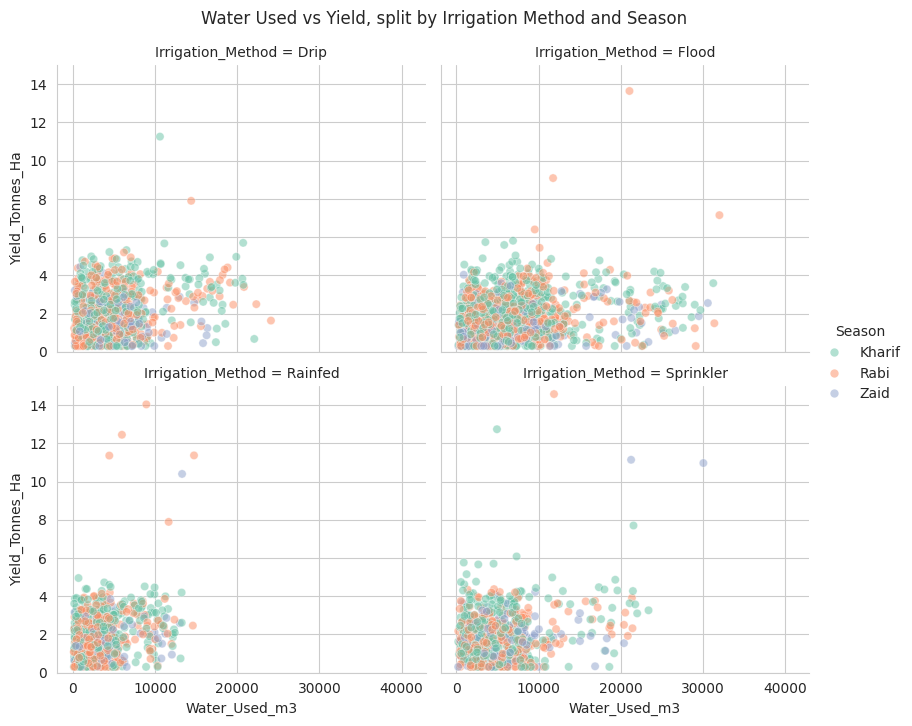

In [34]:
# Water used vs yield
g = sns.relplot(
    data=df, x='Water_Used_m3', y='Yield_Tonnes_Ha', hue='Season', col='Irrigation_Method',
    col_wrap=2, alpha=0.5, palette='Set2', height=3.5, aspect=1.2
)
g.set(ylim=(0, 15))
g.fig.suptitle('Water Used vs Yield, split by Irrigation Method and Season', y=1.03)
plt.show()

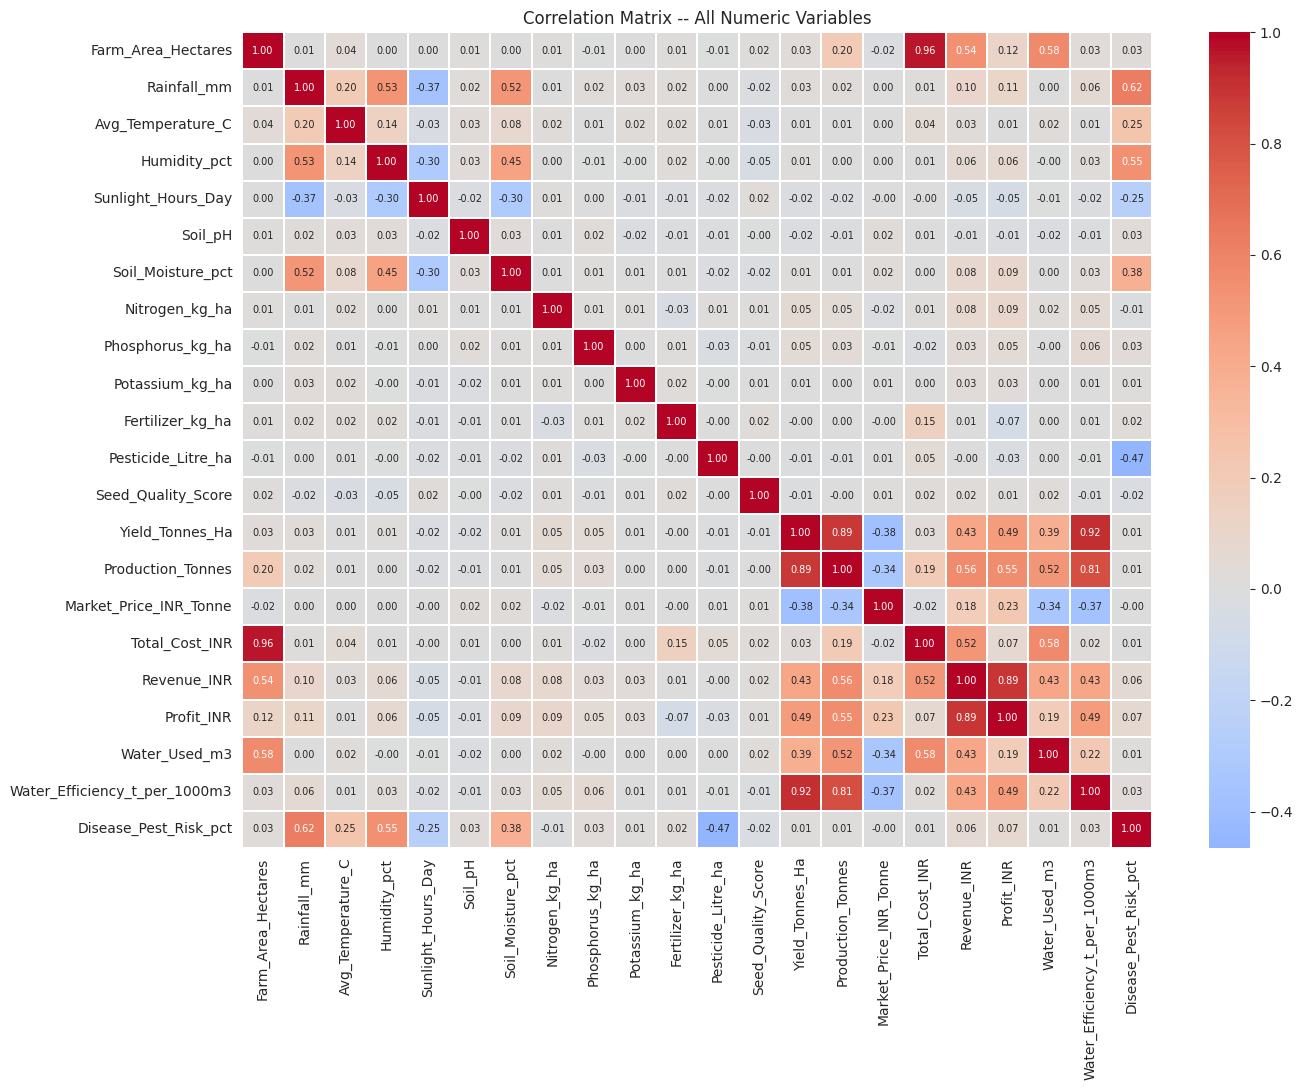

In [35]:
# 9.Correlation Analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Farm_ID', errors='ignore')
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.3, annot_kws={'size': 7})
plt.title('Correlation Matrix -- All Numeric Variables')
plt.tight_layout()
plt.show()

In [36]:
# Top Correlation
print("Top correlations with Yield_Tonnes_Ha:")
print(corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False).drop('Yield_Tonnes_Ha').head(6))
print()
print("Top correlations with Profit_INR:")
print(corr_matrix['Profit_INR'].sort_values(ascending=False).drop('Profit_INR').head(6))

Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.915534
Production_Tonnes                0.885447
Profit_INR                       0.489328
Revenue_INR                      0.433025
Water_Used_m3                    0.387338
Nitrogen_kg_ha                   0.053616
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.489328
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Name: Profit_INR, dtype: float64


In [37]:
## 10.Seasonal comparison
seasonal_summary = df.groupby('Season').agg(
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
).round(2)


seasonal_summary['Loss_Making_Pct'] = (df.assign(is_loss=df['Profit_INR'] < 0).groupby('Season')['is_loss'].mean() * 100).round(1)
seasonal_summary = seasonal_summary.reindex(['Kharif', 'Rabi', 'Zaid'])
seasonal_summary

,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Water_Used_m3,Avg_Yield_t_ha,Avg_Profit_INR,Avg_Disease_Risk_pct,Loss_Making_Pct
Season,,,,,,,
Kharif,852.11,28.45,6102.20,5.63,178914.65,54.47,42.2
Rabi,435.94,23.49,5846.99,5.10,87689.47,40.48,51.1
Zaid,299.12,31.04,6419.89,4.64,-24804.82,38.22,64.5


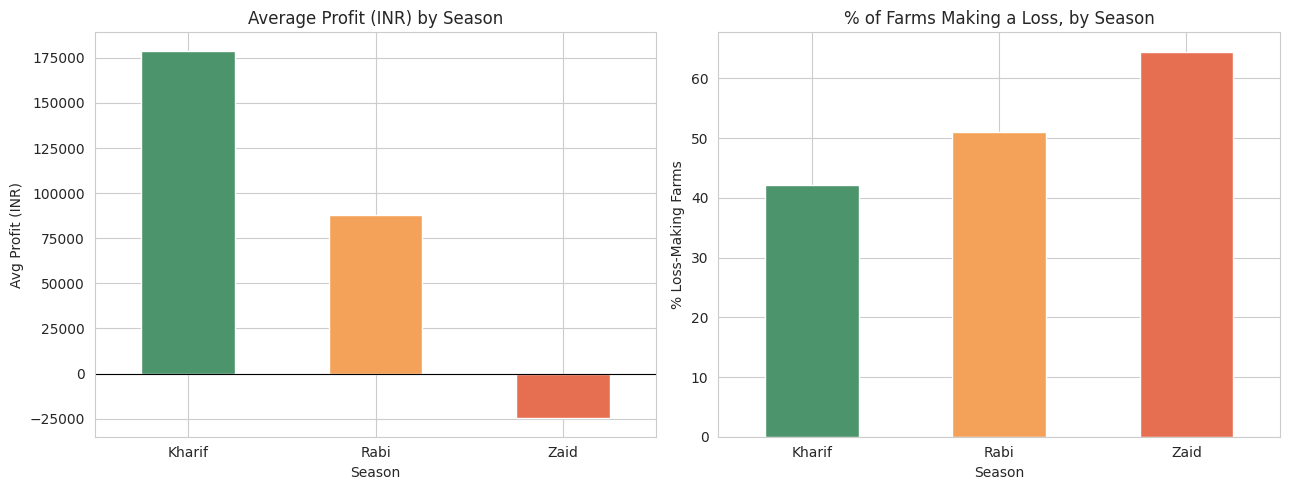

In [38]:
# Seasonal Graphs
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seasonal_summary['Avg_Profit_INR'].plot(kind='bar', ax=axes[0], color=['#4C956C','#F4A259','#E76F51'])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Average Profit (INR) by Season')
axes[0].set_ylabel('Avg Profit (INR)')
axes[0].tick_params(axis='x', rotation=0)

seasonal_summary['Loss_Making_Pct'].plot(kind='bar', ax=axes[1], color=['#4C956C','#F4A259','#E76F51'])
axes[1].set_title('% of Farms Making a Loss, by Season')
axes[1].set_ylabel('% Loss-Making Farms')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [39]:
## Statistical test
h_yield, p_yield = stats.kruskal(
    df.loc[df['Season'] == 'Kharif', 'Yield_Tonnes_Ha'],
    df.loc[df['Season'] == 'Rabi', 'Yield_Tonnes_Ha'],
    df.loc[df['Season'] == 'Zaid', 'Yield_Tonnes_Ha'],
)
print(f"Yield across seasons  -> H = {h_yield:.2f}, p = {p_yield:.4g}", "(significant)" if p_yield < 0.05 else "(not significant)")

Yield across seasons  -> H = 68.84, p = 1.126e-15 (significant)


In [40]:
h_profit, p_profit = stats.kruskal(
    df.loc[df['Season'] == 'Kharif', 'Profit_INR'],
    df.loc[df['Season'] == 'Rabi', 'Profit_INR'],
    df.loc[df['Season'] == 'Zaid', 'Profit_INR'],
)
print(f"Profit across seasons -> H = {h_profit:.2f}, p = {p_profit:.4g}", "(significant)" if p_profit < 0.05 else "(not significant)")

Profit across seasons -> H = 101.93, p = 7.363e-23 (significant)


In [41]:
# 11.Custom Analysis 1: Profitability Deep-Dive
df['Profit_Margin_Pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

crop_loss = df.assign(is_loss=df['Profit_INR'] < 0).groupby('Crop').agg(
    Loss_Making_Pct=('is_loss', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Profit_Margin_Pct=('Profit_Margin_Pct', 'mean'),
)
crop_loss['Loss_Making_Pct'] = (crop_loss['Loss_Making_Pct'] * 100).round(1)
crop_loss['Avg_Profit_INR'] = crop_loss['Avg_Profit_INR'].round(0)
crop_loss['Avg_Profit_Margin_Pct'] = crop_loss['Avg_Profit_Margin_Pct'].round(1)

crop_loss.sort_values('Loss_Making_Pct', ascending=False)

,Loss_Making_Pct,Avg_Profit_INR,Avg_Profit_Margin_Pct
Crop,,,
Wheat,74.1,-123398.0,-91.7
Rice,66.4,-102214.0,-99.4
Maize,63.7,-83978.0,-81.5
Pulses,49.2,-4238.0,-36.5
Groundnut,40.8,44858.0,-28.7
Cotton,34.6,124547.0,-8.2
Chilli,18.0,750878.0,33.8
Sugarcane,11.5,817188.0,27.3


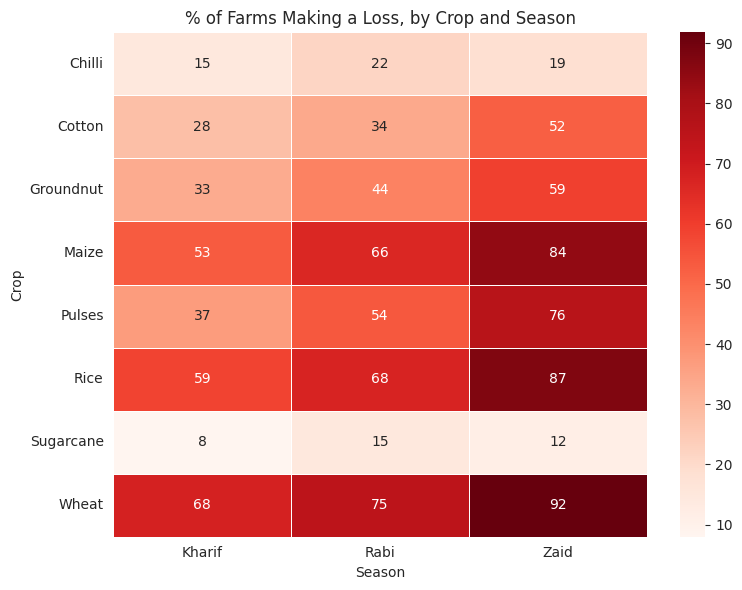

In [42]:

combo_loss = df.assign(is_loss=df['Profit_INR'] < 0).pivot_table(values='is_loss', index='Crop', columns='Season', aggfunc='mean') * 100
combo_loss = combo_loss[['Kharif', 'Rabi', 'Zaid']].round(1)

plt.figure(figsize=(8, 6))
sns.heatmap(combo_loss, annot=True, fmt='.0f', cmap='Reds', linewidths=0.5)
plt.title('% of Farms Making a Loss, by Crop and Season')
plt.tight_layout()
plt.show()

In [43]:
 # 12.Custom Analysis 2: Irrigation Water Efficiency vs Economic Return

df['Profit_per_1000m3'] = (df['Profit_INR'] / df['Water_Used_m3']) * 1000

irrigation_summary = df.groupby('Irrigation_Method').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Profit_per_1000m3=('Profit_per_1000m3', 'mean'),
).round(2).sort_values('Avg_Profit_per_1000m3', ascending=False)

irrigation_summary

,Avg_Yield_t_ha,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Profit_per_1000m3
Irrigation_Method,,,,
Drip,6.68,5918.75,6.27,35180.13
Rainfed,4.60,3549.55,7.56,18825.18
Sprinkler,5.16,6208.26,4.67,13521.54
Flood,4.86,8026.47,3.44,7343.59


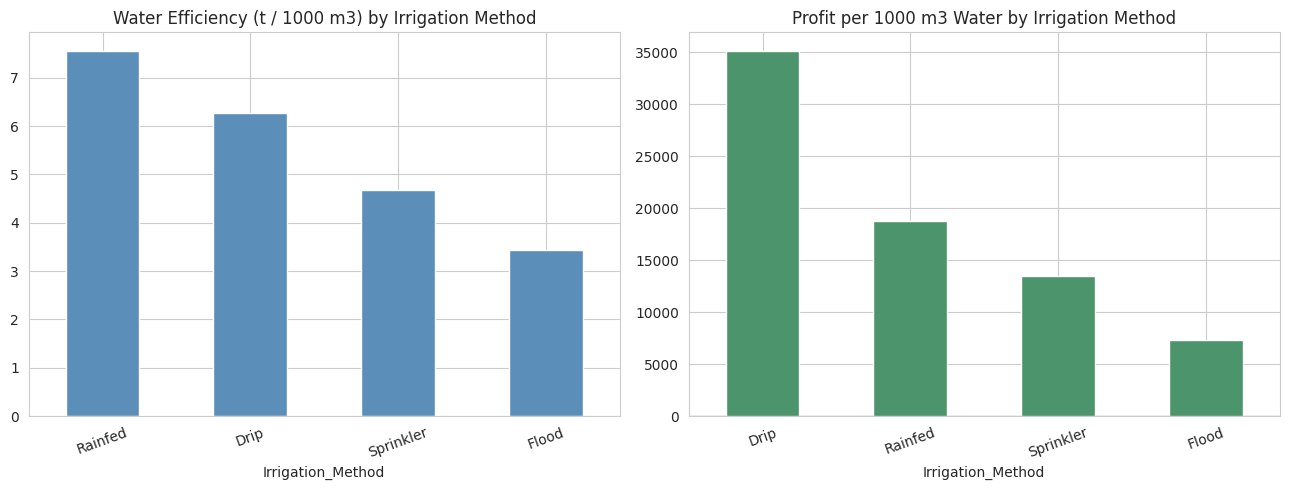

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

irrigation_summary.sort_values('Avg_Water_Efficiency', ascending=False)['Avg_Water_Efficiency'].plot(kind='bar', ax=axes[0], color='#5B8FB9')
axes[0].set_title('Water Efficiency (t / 1000 m3) by Irrigation Method')
axes[0].tick_params(axis='x', rotation=20)

irrigation_summary['Avg_Profit_per_1000m3'].plot(kind='bar', ax=axes[1], color='#4C956C')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Profit per 1000 m3 Water by Irrigation Method')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [45]:
#  13.Custom Analysis 3: Crop Segmentation
crop_profile = df.groupby('Crop').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Price_INR_Tonne=('Market_Price_INR_Tonne', 'mean'),
    Avg_Revenue_INR=('Revenue_INR', 'mean'),
    Avg_Cost_INR=('Total_Cost_INR', 'mean'),
).round(1)

crop_profile['Revenue_to_Cost_Ratio'] = (crop_profile['Avg_Revenue_INR'] / crop_profile['Avg_Cost_INR']).round(2)
crop_profile.sort_values('Revenue_to_Cost_Ratio', ascending=False)

,Avg_Yield_t_ha,Avg_Price_INR_Tonne,Avg_Revenue_INR,Avg_Cost_INR,Revenue_to_Cost_Ratio
Crop,,,,,
Sugarcane,46.9,3490.3,1371980.1,554792.1,2.47
Chilli,1.5,103372.9,1276777.2,525898.9,2.43
Cotton,1.2,67921.1,639423.1,514876.2,1.24
Groundnut,1.3,56310.1,542935.5,498077.4,1.09
Pulses,0.9,71431.6,528465.9,532703.9,0.99
Maize,2.7,20990.5,457068.0,541046.3,0.84
Rice,2.4,22023.1,423615.3,525828.8,0.81
Wheat,2.1,23829.4,400104.9,523503.2,0.76


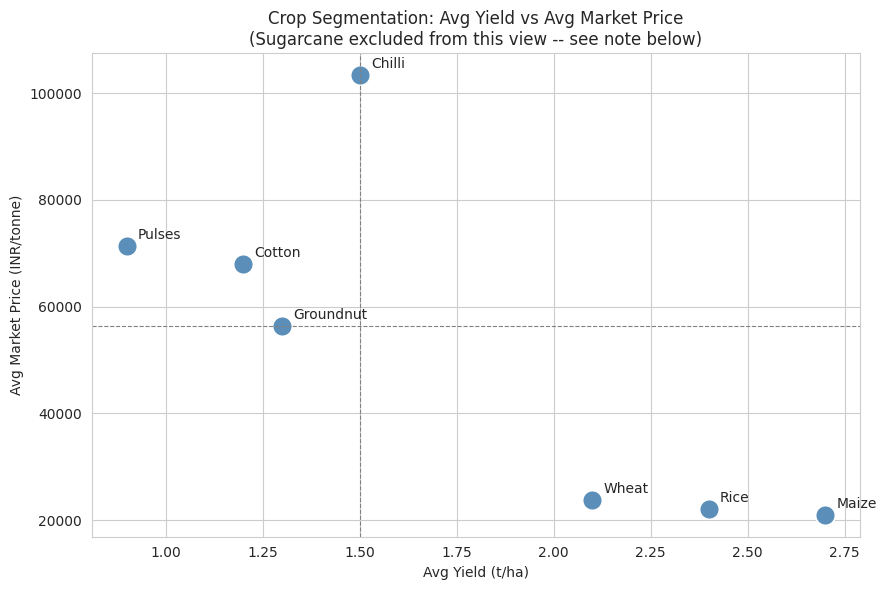

Sugarcane (excluded above for scale): Avg Yield = 46.9 t/ha, Avg Price = INR 3,490/tonne -- the extreme high-volume, low-price crop.


In [46]:
plt.figure(figsize=(9, 6))

plot_data = crop_profile.drop('Sugarcane')

sns.scatterplot(data=plot_data, x='Avg_Yield_t_ha', y='Avg_Price_INR_Tonne', s=200, color='#5B8FB9')
for crop in plot_data.index:
    plt.annotate(crop, (plot_data.loc[crop, 'Avg_Yield_t_ha'], plot_data.loc[crop, 'Avg_Price_INR_Tonne']),
                 textcoords="offset points", xytext=(8, 5), fontsize=10)

plt.axvline(plot_data['Avg_Yield_t_ha'].median(), color='grey', linestyle='--', linewidth=0.8)
plt.axhline(plot_data['Avg_Price_INR_Tonne'].median(), color='grey', linestyle='--', linewidth=0.8)
plt.title('Crop Segmentation: Avg Yield vs Avg Market Price\n(Sugarcane excluded from this view -- see note below)')
plt.xlabel('Avg Yield (t/ha)')
plt.ylabel('Avg Market Price (INR/tonne)')
plt.tight_layout()
plt.show()

sugarcane_yield = crop_profile.loc['Sugarcane', 'Avg_Yield_t_ha']
sugarcane_price = crop_profile.loc['Sugarcane', 'Avg_Price_INR_Tonne']
print(f"Sugarcane (excluded above for scale): Avg Yield = {sugarcane_yield} t/ha, Avg Price = INR {sugarcane_price:,.0f}/tonne "
      f"-- the extreme high-volume, low-price crop.")

# 14. Key Insights

Based on the analysis, the following observations were made:

1. There are noticeable differences in agricultural performance across Kharif, Rabi and Zaid seasons in terms of yield, profit, rainfall and other factors.

2. A considerable share of the records are loss-making, based on the records where Profit_INR is below zero.

3. Crop-wise profitability varies considerably. Some crops perform better economically than others across the different seasons.

4. Yield and market price show a negative relationship in the dataset, which suggests that higher-yield crops are not necessarily the highest-priced crops.

5. The correlation analysis shows very weak relationships between yield and several individual agronomic variables. This suggests that yield cannot be explained by a single input or environmental factor alone.

6. Irrigation methods show differences in water usage, yield and economic performance.

7. The relationship between water efficiency and profit per unit of water is not exactly the same for all irrigation methods, so economic return should also be considered when comparing irrigation options.

8. Some unusually high yield values are associated with specific crops. Crop-wise analysis gives a better comparison than treating all crops as having the same yield scale.

9. The geographic combinations in the dataset should be interpreted carefully because some State-District combinations appear inconsistent.

10. Missing values were present in a small number of variables and were handled before carrying out the main analysis.

# 15. Recommendations

Based on the findings, the following recommendations can be considered:

1. Seasonal crop planning should take differences in yield, profitability and environmental conditions into account.

2. Crops with consistently lower profitability should be studied further in terms of production cost and market price.

3. Irrigation methods should be evaluated using both water efficiency and economic return rather than using only one measure.

4. More detailed agronomic data could help in understanding the effect of fertilizer, soil and environmental factors on yield.

5. Crop-specific profitability and break-even analysis can help in comparing economic performance more clearly.

6. Yield and outlier analysis should preferably be performed within individual crop groups because crop yield scales can vary substantially.

# 16. Limitations

1. Some State-District combinations appear inconsistent, so regional findings should be interpreted with caution.

2. A small number of missing values were imputed before analysis, which may introduce some uncertainty.

3. The dataset represents a single snapshot and does not provide multi-year trends.

4. Correlation does not imply causation. Other factors that may affect agricultural performance are not included in the dataset.

5. The dataset does not provide a detailed breakdown of individual costs such as labor, seed and fertilizer costs.

6. Weak correlations between some agricultural inputs and yield should not be interpreted as proof that those factors are unimportant. The relationship may depend on other variables or the level of detail in the dataset.

# 17. Conclusion

This project examined agricultural performance across different seasons using data cleaning, exploratory analysis, visualization, correlation analysis and statistical testing.

The results show that agricultural performance varies across seasons and crops. Differences can also be observed in profitability, water usage, irrigation performance and environmental conditions.

The analysis also shows that some variables have stronger relationships with agricultural outcomes than others. Crop-wise and season-wise comparisons provide more useful insights than looking at the overall dataset alone.

Overall, the project provides a data-driven view of seasonal agricultural performance and highlights areas where further analysis and better data collection could support agricultural planning.